In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/diabetes.csv")

In [20]:
df.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,33.6,0.627,50,1
1,1,85.0,66.0,26.6,0.351,31,0
2,8,183.0,64.0,23.3,0.672,32,1
3,1,89.0,66.0,28.1,0.167,21,0
4,0,137.0,40.0,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Number of patients without diabetes: 500
Number of patients with diabetes: 268


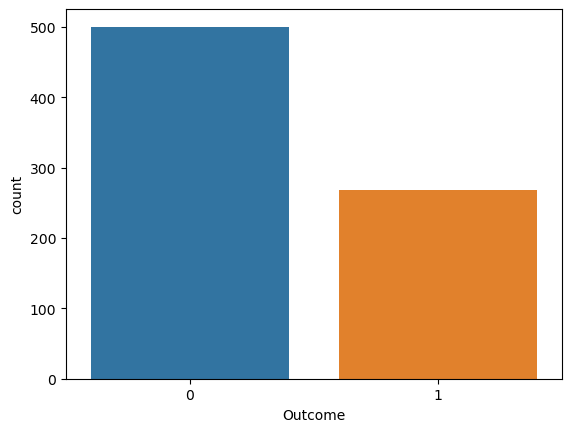

In [7]:
sns.countplot(data=df, x = 'Outcome', label='Count')
LD, NLD = df['Outcome'].value_counts()
print('Number of patients without diabetes: {}'.format(LD))
print('Number of patients with diabetes: {}'.format(NLD))

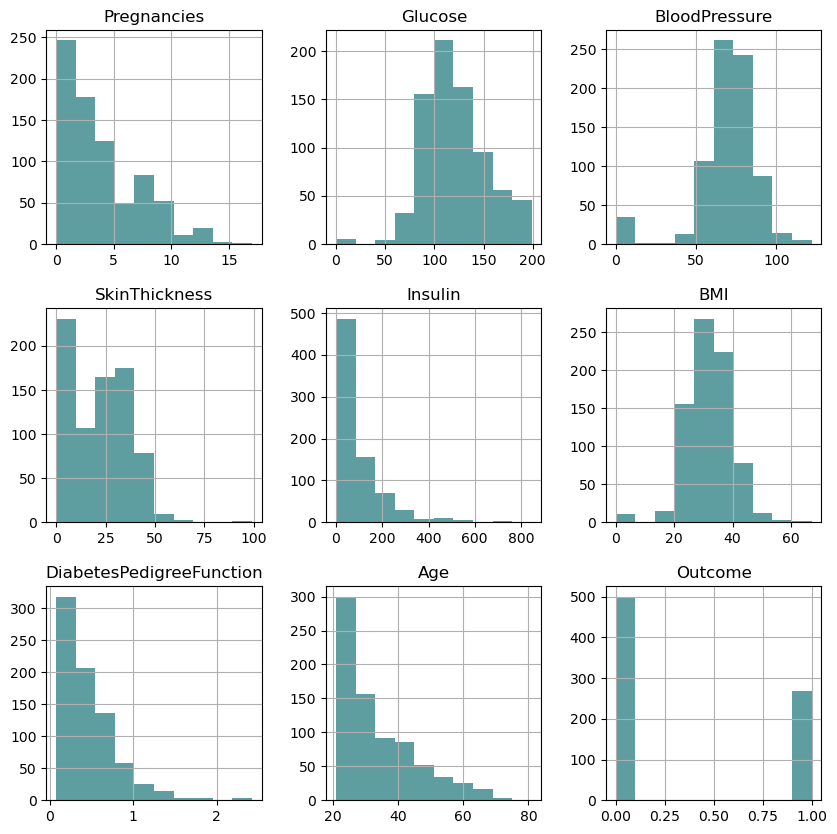

In [8]:
df.hist(figsize = (10,10), color = "#5F9EA0")
plt.show() 

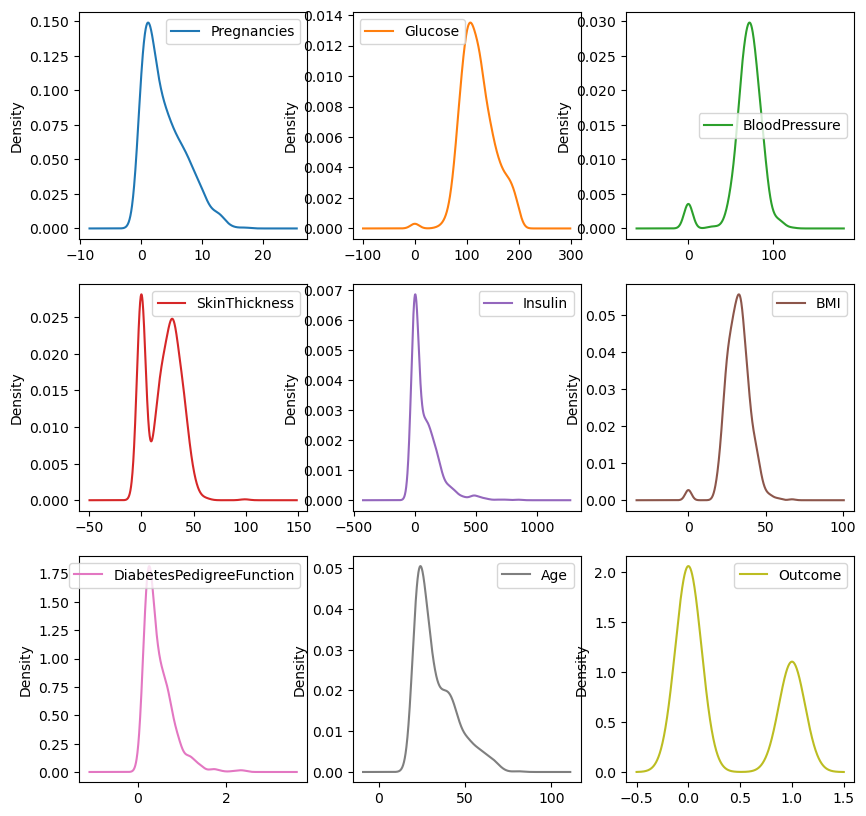

In [9]:
df.plot(kind='density', subplots=True, layout=(3,3), sharex=False , figsize =(10,10))
plt.show()

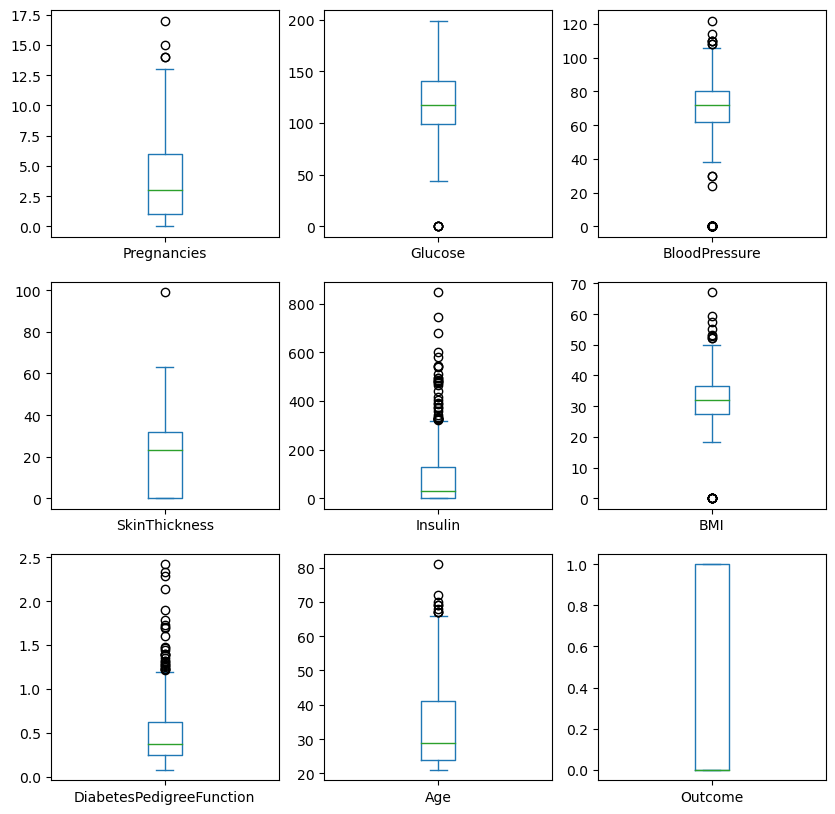

In [10]:
df.plot(kind='box', subplots=True, layout=(3,3), sharex=False,sharey=False ,figsize =(10,10))
plt.show()

In [12]:
y = df.Outcome
list = ['Outcome']
x = df.drop(list,axis = 1 )
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


<Axes: >

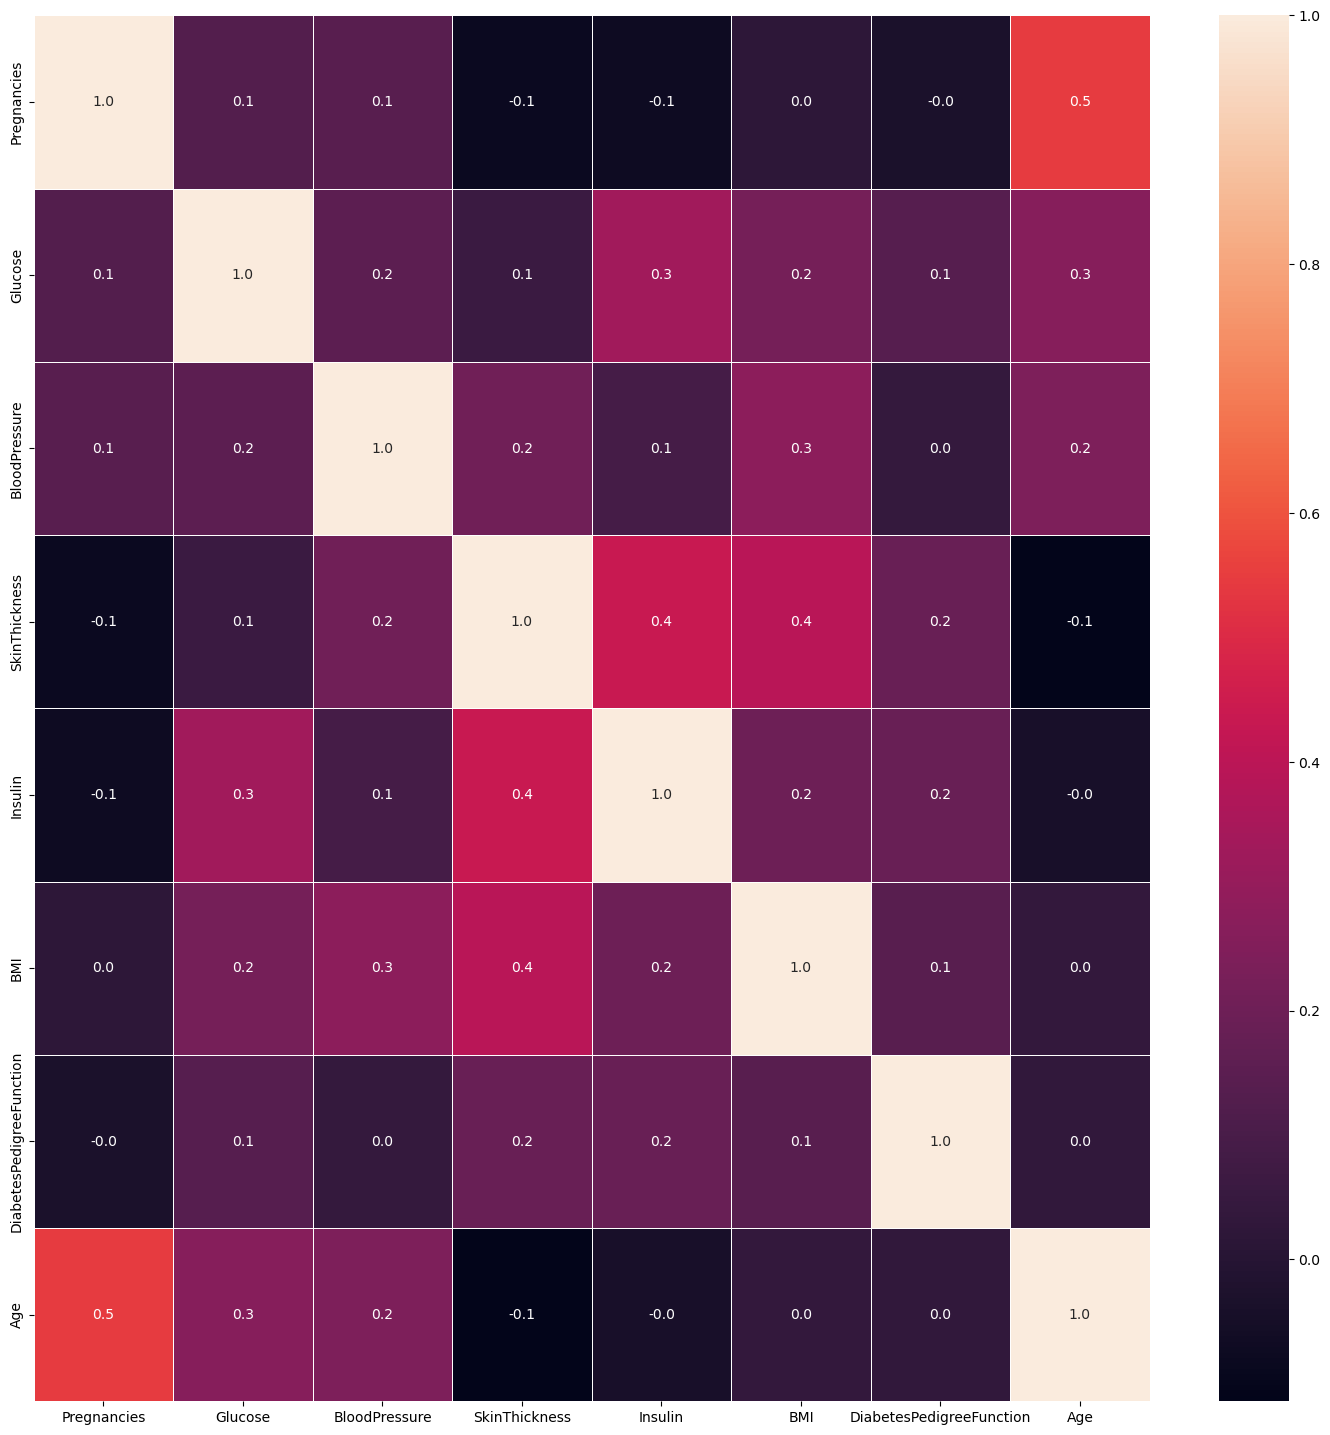

In [13]:
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(x.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

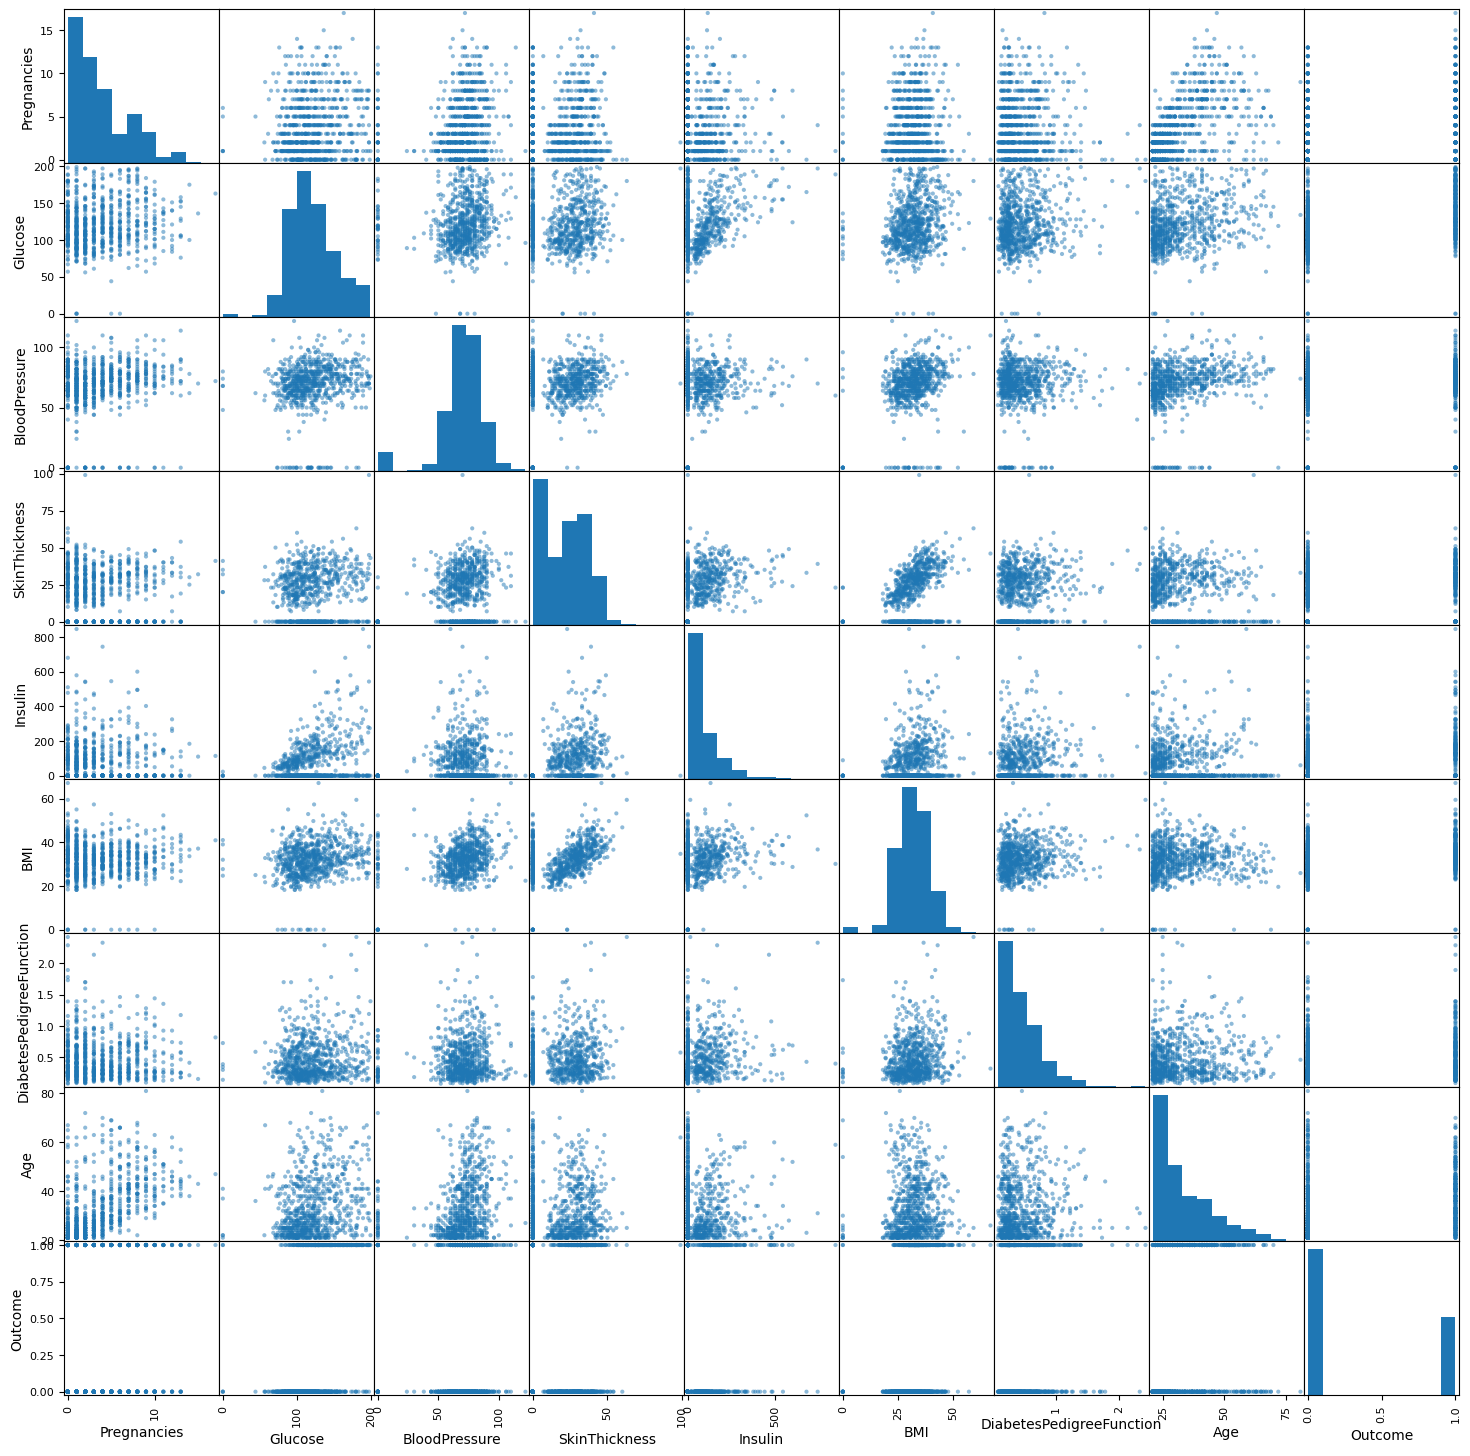

In [14]:
from matplotlib import pyplot
from pandas import read_csv
from pandas.plotting import scatter_matrix

scatter_matrix(df ,figsize = (18,18))
pyplot.show()

In [15]:

df['Glucose'].replace(0, np.nan, inplace=True)
df['BloodPressure'].replace(0, np.nan, inplace=True)
df['SkinThickness'].replace(0, np.nan, inplace=True)
df['Insulin'].replace(0, np.nan, inplace=True)
df['BMI'].replace(0, np.nan, inplace=True)

In [16]:
df.drop(['SkinThickness' ,'Insulin'], axis=1, inplace=True)
df = df.dropna(axis=0)

In [17]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [21]:
df_outcome_1 = df[df['Outcome'] == 1].copy()
i = len(df_outcome_1)
df_outcome_0 = df[df['Outcome'] == 0].sample(i, random_state=1)
df_balanced = df_outcome_0._append(df_outcome_1)
df_balanced = df[cols]


In [22]:
y = df_balanced['Outcome']
X = df_balanced.drop('Outcome', axis=1)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
#Spliting the dataset into train and test. Where 15% of the data is split into test data and 85% to train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier

In [26]:
random_model = RandomForestClassifier()
random_model.fit(X_train,y_train)

RandomForestClassifier()

In [27]:
svc_model = SVC()
svc_model.fit(X_train,y_train)

SVC()

In [28]:
ada_model = AdaBoostClassifier()
ada_model.fit(X_train,y_train)

AdaBoostClassifier()

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report

In [30]:
def report(model):
    preds = model.predict(X_test)
    print(classification_report(y_test,preds))
    ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        78
           1       0.64      0.52      0.57        31

    accuracy                           0.78       109
   macro avg       0.73      0.70      0.71       109
weighted avg       0.77      0.78      0.77       109



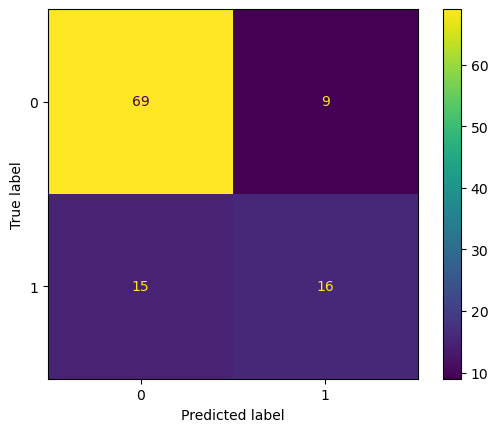

In [31]:
print("Random Forest")
report(random_model)

SVC
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        78
           1       0.65      0.42      0.51        31

    accuracy                           0.77       109
   macro avg       0.72      0.66      0.68       109
weighted avg       0.76      0.77      0.75       109



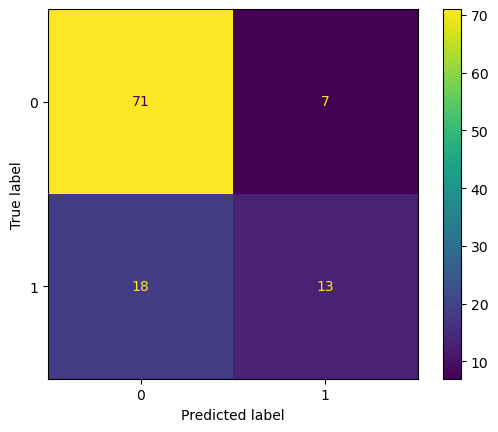

In [32]:
print("SVC")
report(svc_model)

AdaBoost Model
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        78
           1       0.62      0.58      0.60        31

    accuracy                           0.78       109
   macro avg       0.73      0.72      0.72       109
weighted avg       0.78      0.78      0.78       109



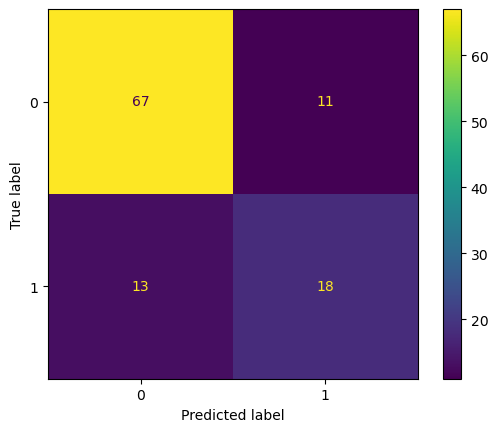

In [33]:
print("AdaBoost Model")
report(ada_model)

In [34]:
import joblib

In [35]:
joblib.dump(svc_model,'Diabetes.pkl')

['Diabetes.pkl']